In [2]:
import os
import json
import numpy as np
import pandas as pd

# 1. Print the current directory of the notebook
print("Current Working Directory:", os.getcwd())

# 2. Define relative paths pointing to the processed folder
path_X_train = "../data/processed/X_train.csv"
path_X_test = "../data/processed/X_test.csv"
path_y_train = "../data/processed/y_train.npy"
path_y_test = "../data/processed/y_test.npy"
path_mapping = "../data/processed/label_mapping.json"

# 3. Check if all required files exist before loading
files_to_check = {
    "X_train": path_X_train,
    "X_test": path_X_test,
    "y_train": path_y_train,
    "y_test": path_y_test,
    "label_mapping": path_mapping
}

all_found = True
for name, file_path in files_to_check.items():
    exists = os.path.exists(file_path)
    print(f"[{'FOUND' if exists else 'MISSING'}] {name} -> {os.path.abspath(file_path)}")
    if not exists:
        all_found = False

# 4. If all files exist, load and verify shapes
if all_found:
    X_train = pd.read_csv(path_X_train)
    X_test = pd.read_csv(path_X_test)
    y_train = np.load(path_y_train)
    y_test = np.load(path_y_test)

    with open(path_mapping, "r") as f:
        label_mapping = json.load(f)

    target_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

    print("\nVerification Passed:")
    print(f"  • X_train shape: {X_train.shape} (Expected: ~47764 rows, 23 columns)")
    print(f"  • X_test shape:  {X_test.shape}  (Expected: ~11942 rows, 23 columns)")
    print(f"  • y_train count: {len(y_train)}")
    print(f"  • y_test count:  {len(y_test)}")
    print(f"  • Classes mapped: {len(target_names)} categories")
else:
    print("\nVerification Failed: One or more files are missing. Check directory paths.")

Current Working Directory: C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\notebooks
[FOUND] X_train -> C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\data\processed\X_train.csv
[FOUND] X_test -> C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\data\processed\X_test.csv
[FOUND] y_train -> C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\data\processed\y_train.npy
[FOUND] y_test -> C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\data\processed\y_test.npy
[FOUND] label_mapping -> C:\Users\LOQ\Projects\encrypted-traffic-classifier-xai\data\processed\label_mapping.json

Verification Passed:
  • X_train shape: (47764, 23) (Expected: ~47764 rows, 23 columns)
  • X_test shape:  (11942, 23)  (Expected: ~11942 rows, 23 columns)
  • y_train count: 47764
  • y_test count:  11942
  • Classes mapped: 14 categories


In [3]:
from sklearn.ensemble import RandomForestClassifier

# Configure Random Forest with balanced weighting
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1  # Uses all available CPU cores to train faster
)

print("Training Balanced Random Forest... (this typically takes 30–90 seconds)")
rf_balanced.fit(X_train, y_train)
print("Training complete!")

Training Balanced Random Forest... (this typically takes 30–90 seconds)
Training complete!


In [4]:
from sklearn.metrics import classification_report, accuracy_score

# Generate predictions on the test set
y_pred = rf_balanced.predict(X_test)

# Calculate and display metrics
acc = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

Overall Accuracy: 90.88%

=== Classification Report ===
               precision    recall  f1-score   support

     BROWSING     0.9291    0.9505    0.9397      2000
         CHAT     0.8664    0.8283    0.8469       501
           FT     0.9376    0.7371    0.8254       795
         MAIL     0.9125    0.8022    0.8538       273
          P2P     0.9620    0.9812    0.9715       800
    STREAMING     0.9310    0.8405    0.8834       257
         VOIP     0.9897    0.9653    0.9774      1297
 VPN-BROWSING     0.9157    0.9175    0.9166      2000
     VPN-CHAT     0.8333    0.7570    0.7934       568
       VPN-FT     0.8555    0.8618    0.8587       941
     VPN-MAIL     0.8929    0.9550    0.9229       489
      VPN-P2P     0.7071    0.9649    0.8161       683
VPN-STREAMING     0.9819    0.9731    0.9775       223
     VPN-VOIP     0.9680    0.9507    0.9593      1115

     accuracy                         0.9088     11942
    macro avg     0.9059    0.8918    0.8959     11942
 weight

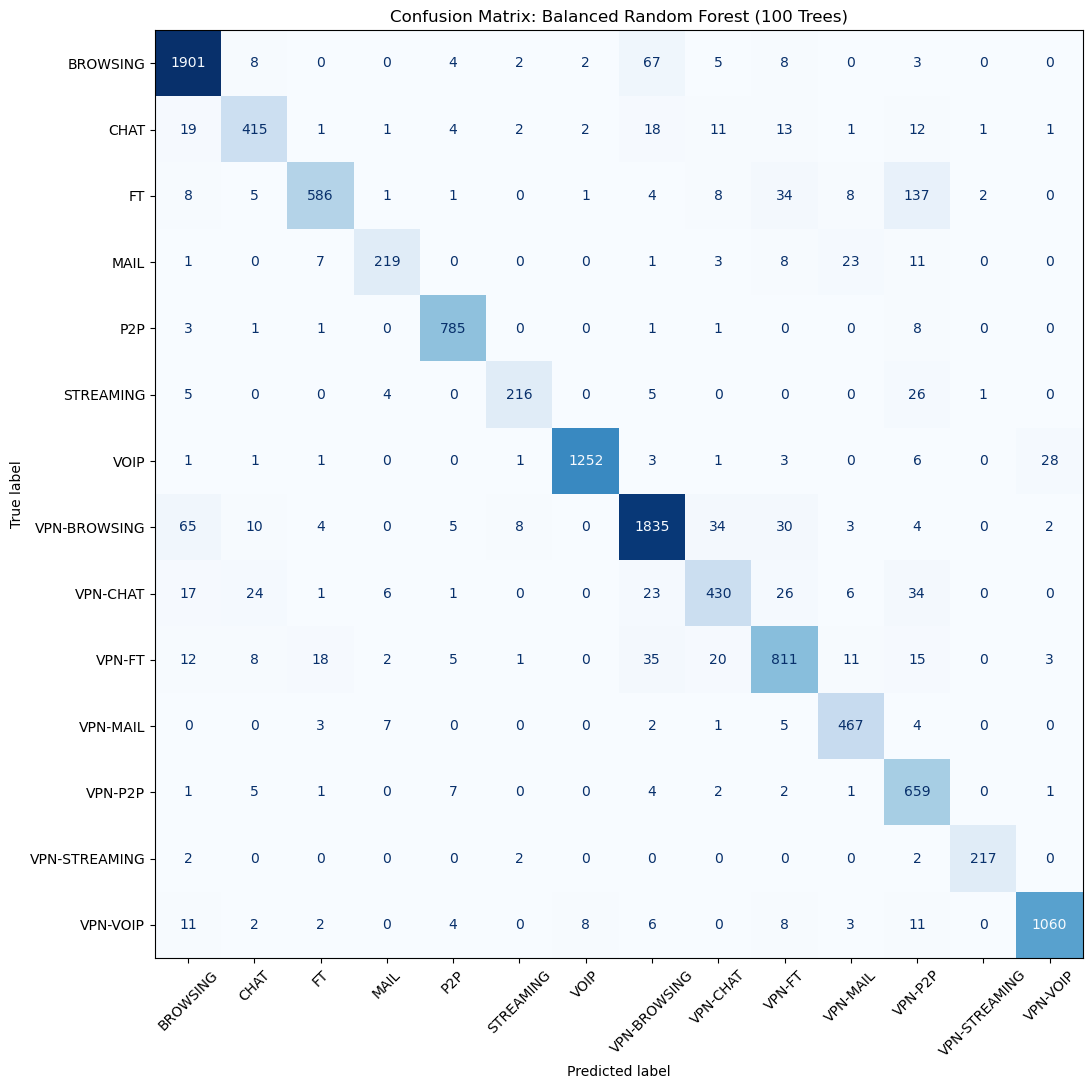

Confusion matrix saved successfully to: ../results/confusion_matrix_rf_balanced.png


In [5]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create results folder if it doesn't exist
os.makedirs("../results", exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 11))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_names,
    xticks_rotation=45,
    cmap=plt.cm.Blues,
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix: Balanced Random Forest (100 Trees)")
plt.tight_layout()

# Save plot
save_path = "../results/confusion_matrix_rf_balanced.png"
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Confusion matrix saved successfully to: {save_path}")

In [6]:
import joblib

os.makedirs("../models", exist_ok=True)
model_path = "../models/random_forest_balanced.pkl"
joblib.dump(rf_balanced, model_path)

print(f"Balanced RF model saved successfully to: {model_path}")

Balanced RF model saved successfully to: ../models/random_forest_balanced.pkl
